load data


In [9]:
import json
import numpy as np

# Load embeddings
embeddings = np.load("../embeddings/product_embeddings.npy")

# Load metadata
with open("../embeddings/embedding_metadata.json", "r") as f:
    data = json.load(f)

descriptions = [item["description"] for item in data]
categories = [item["category"] for item in data]

print("Total products:", len(descriptions))
print("Embedding shape:", embeddings.shape)

Total products: 2457
Embedding shape: (2457, 384)


Similarity Check (Core Evaluation)

In [10]:
from sklearn.metrics.pairwise import cosine_similarity

# Pick a product
index = 50  # you can change this

query_embedding = embeddings[index]

similarities = cosine_similarity(
    [query_embedding],
    embeddings
)[0]

# Get top 5 similar items
top_indices = similarities.argsort()[-6:][::-1]  # include itself

print("🔍 Query Product:\n")
print(descriptions[index])

print("\n🎯 Similar Products:\n")

for i in top_indices:
    print(descriptions[i])
    print("Score:", round(similarities[i], 3))
    print("-" * 50)

🔍 Query Product:

luxury metal desk in white color. price: 486

🎯 Similar Products:

luxury metal desk in white color. price: 486
Score: 1.0
--------------------------------------------------
luxury metal desk in white color. price: 368
Score: 0.987
--------------------------------------------------
luxury metal desk in white color. price: 479
Score: 0.984
--------------------------------------------------
luxury metal desk in white color. price: 497
Score: 0.983
--------------------------------------------------
luxury metal desk in white color. price: 405
Score: 0.982
--------------------------------------------------
luxury metal desk in white color. price: 491
Score: 0.982
--------------------------------------------------


Query-Based Testing

In [11]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

query = "modern wooden chair"

query_embedding = model.encode([query])

similarities = cosine_similarity(query_embedding, embeddings)[0]

top_indices = similarities.argsort()[-5:][::-1]

print("🔍 Query:", query)

print("\n🎯 Results:\n")

for i in top_indices:
    print(descriptions[i])
    print("Score:", round(similarities[i], 3))
    print("-" * 50)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 5438.58it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


🔍 Query: modern wooden chair

🎯 Results:

modern wood chair in green color. price: 340
Score: 0.713
--------------------------------------------------
modern wood chair in red color. price: 238
Score: 0.708
--------------------------------------------------
modern wood chair in green color. price: 206
Score: 0.703
--------------------------------------------------
modern wood chair in green color. price: 306
Score: 0.701
--------------------------------------------------
modern wood chair in black color. price: 304
Score: 0.701
--------------------------------------------------


PCA Visualization

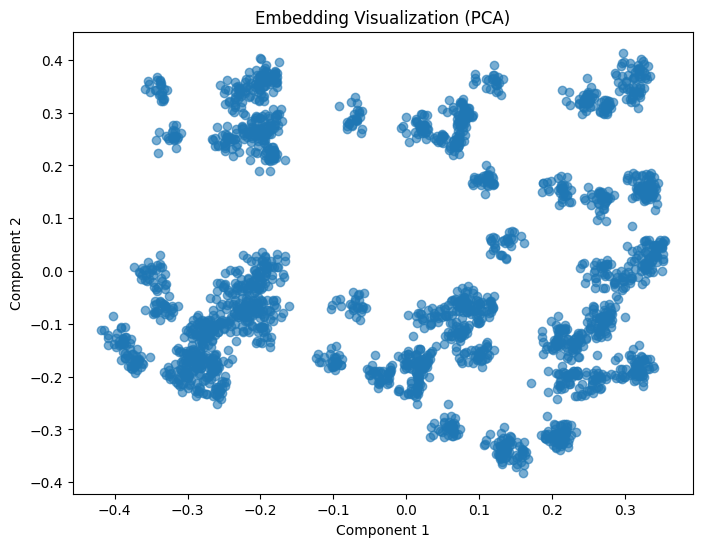

In [12]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
reduced = pca.fit_transform(embeddings)

plt.figure(figsize=(8,6))
plt.scatter(reduced[:,0], reduced[:,1], alpha=0.6)

plt.title("Embedding Visualization (PCA)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")

plt.show()

Color by Category

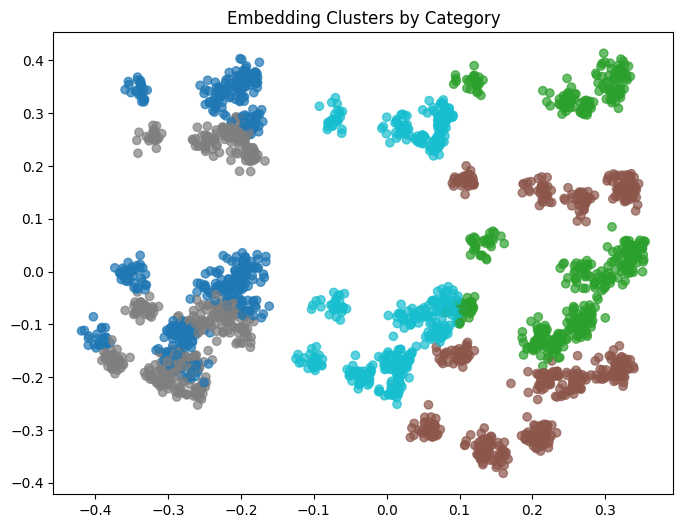

In [13]:
import matplotlib.pyplot as plt

# Convert categories to numeric labels
unique_categories = list(set(categories))
category_map = {cat: i for i, cat in enumerate(unique_categories)}

labels = [category_map[c] for c in categories]

plt.figure(figsize=(8,6))
scatter = plt.scatter(
    reduced[:,0],
    reduced[:,1],
    c=labels,
    cmap='tab10',
    alpha=0.7
)

plt.title("Embedding Clusters by Category")
plt.show()

Clustering

In [14]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42)
cluster_labels = kmeans.fit_predict(embeddings)

print("Cluster assignments (first 20):")
print(cluster_labels[:20])

Cluster assignments (first 20):
[3 2 4 4 2 4 1 1 3 1 1 0 0 0 0 4 3 3 1 3]


Failure Case

In [15]:
query = "cheap plastic chair"

query_embedding = model.encode([query])

similarities = cosine_similarity(query_embedding, embeddings)[0]
top_indices = similarities.argsort()[-5:][::-1]

print("🔍 Query:", query)

print("\n⚠️ Observations:\n")

for i in top_indices:
    print(descriptions[i])
    print("Score:", round(similarities[i], 3))
    print("-" * 50)

🔍 Query: cheap plastic chair

⚠️ Observations:

minimalist plastic chair in brown color. price: 87
Score: 0.789
--------------------------------------------------
minimalist plastic chair in red color. price: 128
Score: 0.787
--------------------------------------------------
minimalist plastic chair in green color. price: 172
Score: 0.786
--------------------------------------------------
modern plastic chair in black color. price: 312
Score: 0.785
--------------------------------------------------
modern plastic chair in brown color. price: 242
Score: 0.785
--------------------------------------------------


## Objective  TASK 6

The goal of this section is to optimize the embedding-based recommendation system by:

- Reducing embedding dimensionality (PCA)
- Comparing different embedding models
- Measuring retrieval accuracy
- Improving search performance

This helps improve efficiency, scalability, and recommendation quality.

In [16]:
import json
import numpy as np

# Load embeddings
embeddings = np.load("../embeddings/product_embeddings.npy")

# Load metadata
with open("../embeddings/embedding_metadata.json", "r") as f:
    data = json.load(f)

descriptions = [item["description"] for item in data]
categories = [item["category"] for item in data]

print("Total products:", len(descriptions))
print("Embedding shape:", embeddings.shape)

Total products: 2457
Embedding shape: (2457, 384)


### Explanation
We load the precomputed embeddings and metadata. Each embedding corresponds to a product description.

In [17]:
from sklearn.decomposition import PCA

print("Original shape:", embeddings.shape)

# Reduce dimensions
pca = PCA(n_components=50)
reduced_embeddings = pca.fit_transform(embeddings)

print("Reduced shape:", reduced_embeddings.shape)

Original shape: (2457, 384)
Reduced shape: (2457, 50)


### Explanation
PCA reduces embedding size from 384 → 50 dimensions while preserving most information.

Benefits:
- Faster search
- Less memory usage
- Scalable system

In [18]:
np.save("../embeddings/product_embeddings_pca.npy", reduced_embeddings)
print("✅ PCA embeddings saved")

✅ PCA embeddings saved


In [19]:
# compare embedding models

from sentence_transformers import SentenceTransformer

models = [
    "all-MiniLM-L6-v2",
    "all-mpnet-base-v2",
    "BAAI/bge-base-en-v1.5"
]

sample_texts = descriptions[:300]  # small sample for speed

model_results = {}

for model_name in models:
    print(f"\n🔹 Testing {model_name}")
    
    model = SentenceTransformer(model_name)
    emb = model.encode(sample_texts)
    
    model_results[model_name] = emb.shape

print("\nModel Output Shapes:")
print(model_results)


🔹 Testing all-MiniLM-L6-v2


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7741.48it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



🔹 Testing all-mpnet-base-v2


c:\Users\tusha\Desktop\CLG_PROJECT\RECOMMENDATION_SYSTEM\myenv\lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\tusha\.cache\huggingface\hub\models--sentence-transformers--all-mpnet-base-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4764.65it/


🔹 Testing BAAI/bge-base-en-v1.5


c:\Users\tusha\Desktop\CLG_PROJECT\RECOMMENDATION_SYSTEM\myenv\lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\tusha\.cache\huggingface\hub\models--BAAI--bge-base-en-v1.5. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 5815.96it/s]
BertModel LOAD 


Model Output Shapes:
{'all-MiniLM-L6-v2': (300, 384), 'all-mpnet-base-v2': (300, 768), 'BAAI/bge-base-en-v1.5': (300, 768)}


### Explanation

We compare different embedding models:

- MiniLM → Fast, lightweight
- MPNet → Balanced performance
- BGE → Best semantic quality

This helps select the best model for the system.

In [20]:
from sklearn.metrics.pairwise import cosine_similarity

def evaluate_accuracy(embeddings, data, sample_size=100):
    correct = 0

    for i in range(sample_size):
        query = embeddings[i]

        sims = cosine_similarity([query], embeddings)[0]
        top_idx = sims.argsort()[-2]  # exclude itself

        if data[i]["category"] == data[top_idx]["category"]:
            correct += 1

    return correct / sample_size


accuracy = evaluate_accuracy(embeddings, data)
print("🔍 Retrieval Accuracy:", round(accuracy, 3))

🔍 Retrieval Accuracy: 1.0


### Explanation

Accuracy is measured by checking whether the retrieved product belongs to the same category as the query.

Higher accuracy indicates better semantic understanding.

In [21]:
from sklearn.preprocessing import normalize

normalized_embeddings = normalize(embeddings)

print("✅ Embeddings normalized")

✅ Embeddings normalized


### Explanation

Normalization ensures consistent similarity calculations and improves cosine similarity performance.

In [22]:
# Example improvement ideas (not execution-heavy)

TOP_K = 15  # retrieve more
THRESHOLD = 0.35  # filter later

print("Top-K increased to:", TOP_K)
print("Threshold set to:", THRESHOLD)

Top-K increased to: 15
Threshold set to: 0.35


### Explanation

- Increasing Top-K improves diversity
- Threshold removes irrelevant results
- Leads to better recommendation quality

In [ ]:
import umap

reducer = umap.UMAP(n_components=2, random_state=42)
embedding_2d = reducer.fit_transform(embeddings)

print("UMAP completed:", embedding_2d.shape)

c:\Users\tusha\Desktop\CLG_PROJECT\RECOMMENDATION_SYSTEM\myenv\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP completed: (2457, 2)


: 